In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
from itertools import cycle

from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_auc_score

In [3]:
import pandas as pd
import numpy as np
import os

In [4]:
from sklearn import linear_model
from scipy.stats import zscore
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
import statsmodels.api as sm

In [5]:
import sys
print(sys.path) 
sys.path.append("/cellar/users/mpagadal/Programs/anaconda3/lib/python3.7/site-packages")

['/data/cellardata2/users/mpagadal/projects/TestosteroneGWAS/prs', '/nrnb/opt/anaconda3.7/lib/python37.zip', '/nrnb/opt/anaconda3.7/lib/python3.7', '/nrnb/opt/anaconda3.7/lib/python3.7/lib-dynload', '', '/cellar/users/mpagadal/.local/lib/python3.7/site-packages', '/nrnb/opt/anaconda3.7/lib/python3.7/site-packages', '/nrnb/opt/anaconda3.7/lib/python3.7/site-packages/IPython/extensions', '/cellar/users/mpagadal/.ipython']


In [6]:
import joblib
from regressors import stats

In [7]:
sys.path.append("/cellar/users/jtalwar/anaconda3/lib/python3.7/site-packages")
import optuna

In [7]:
# 166000 individuals
# split(90:10)
# 90 --> optuna
# 90 --> 90:10 optimized
# pickle


### Make PRS

In [59]:
# compiled_clumps=pd.DataFrame()

# for x in os.listdir("../discovery/data/clumps/"):
#     clumps=pd.read_csv("../discovery/data/clumps/"+x,delimiter="\t")
#     compiled_clumps=compiled_clumps.append(clumps)

# mp_rsid=dict(zip(compiled_clumps["0"],compiled_clumps["rsid"]))
# metal=pd.read_csv("../discovery/data/metal/METAANALYSIS1.TBL.filt",delimiter="\t",header=None)
# print(len(metal[metal[5]<.00000005]))
# prs_snps=metal[metal[5]<.00000005]
# prs_snps["rsid"]=prs_snps[0].map(mp_rsid)
# prs_snps["rsid"].to_csv("extract.metal.prs.snps.txt",header=None,index=None,sep="\t")

### run recode.sh

### run compile-raw.py

### plot quantile plot

In [96]:
prs=pd.read_csv("eur.metal.testosterone.prs.tsv",delimiter="\t")
cov=pd.read_csv("/cellar/users/mpagadal/Data2/projects/TestosteroneGWAS/validation/data/UKBB/covariates/cov.tsv",delimiter="\t")

In [97]:
prs["testosterone ng/dl"]=prs["testosterone"]*28.842

In [98]:
prs=pd.merge(prs,cov,on="FID",how="left")
prs=prs[prs["SEX"]==0]

In [99]:
quant=[]
beta=[]
error=[]

for i in range(10):
    quant.append(str(10*i))
    df_filt=prs[(prs["PRS"]>prs["PRS"].quantile(.1*i))&(prs["PRS"]<prs["PRS"].quantile(.1*(i+1)))]
    beta.append(df_filt["testosterone ng/dl"].mean())
    error.append(2*(df_filt["testosterone ng/dl"].std()/np.sqrt(len(df_filt))))

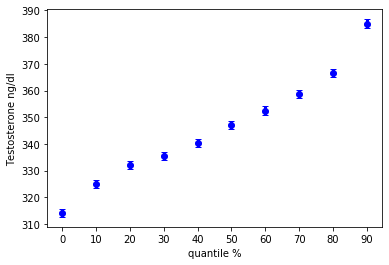

In [100]:
plt.errorbar(quant,beta,yerr=error,fmt='o', color='blue', ecolor='blue', elinewidth=3, capsize=3)
plt.xlabel("quantile %")
plt.ylabel("Testosterone ng/dl")
plt.savefig("./plots/testosterone.quantile.pdf")

### Get phecode incidence

In [101]:
icd=[]
frac=[]

for x in prs.columns[5:11]:
    icd.append(x)
    frac.append(len(prs[prs[x]==2])/len(prs))

incidence=pd.DataFrame({"icd":icd,"frac":frac})

(0, 0.5)

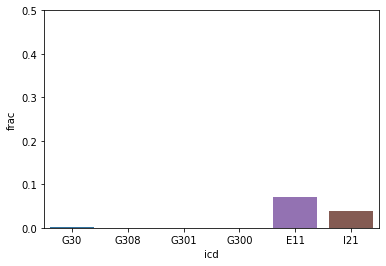

In [102]:
sns.barplot(x="icd",y="frac",data=incidence)
plt.ylim(0,0.5)

In [103]:
len(prs)

176241

In [104]:
prs["AGE"]=prs["AGE"].astype(float)

Text(0, 0.5, '# individuals')

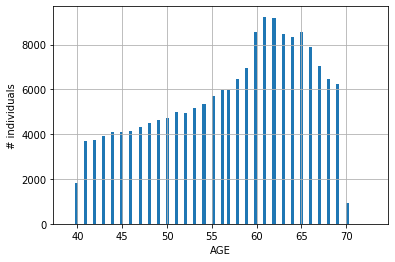

In [105]:
prs["AGE"].hist(bins=100)
plt.xlabel("AGE")
plt.ylabel("# individuals")

### get quantile plot of age

In [107]:
quant=[]
beta=[]
error=[]

for i in range(10):
    quant.append(str(10*i))
    df_filt=prs[(prs["PRS"]>prs["PRS"].quantile(.1*i))&(prs["PRS"]<prs["PRS"].quantile(.1*(i+1)))]
    beta.append(df_filt["AGE"].mean())
    error.append(2*(df_filt["AGE"].std()/np.sqrt(len(df_filt))))

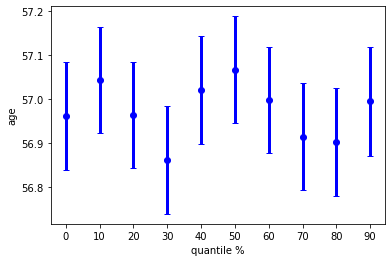

In [108]:
plt.errorbar(quant,beta,yerr=error,fmt='o', color='blue', ecolor='blue', elinewidth=3, capsize=3)
plt.xlabel("quantile %")
plt.ylabel("age")
plt.savefig("./plots/testosterone.age.quantile.pdf")

### Get logistic regression for model

In [109]:
for x in prs.columns[4:11]:
    prs[x]=prs[x].map({1:0,2:1})

In [110]:
prs["age_cat"]=np.where(prs["AGE"]>60,"old","young")

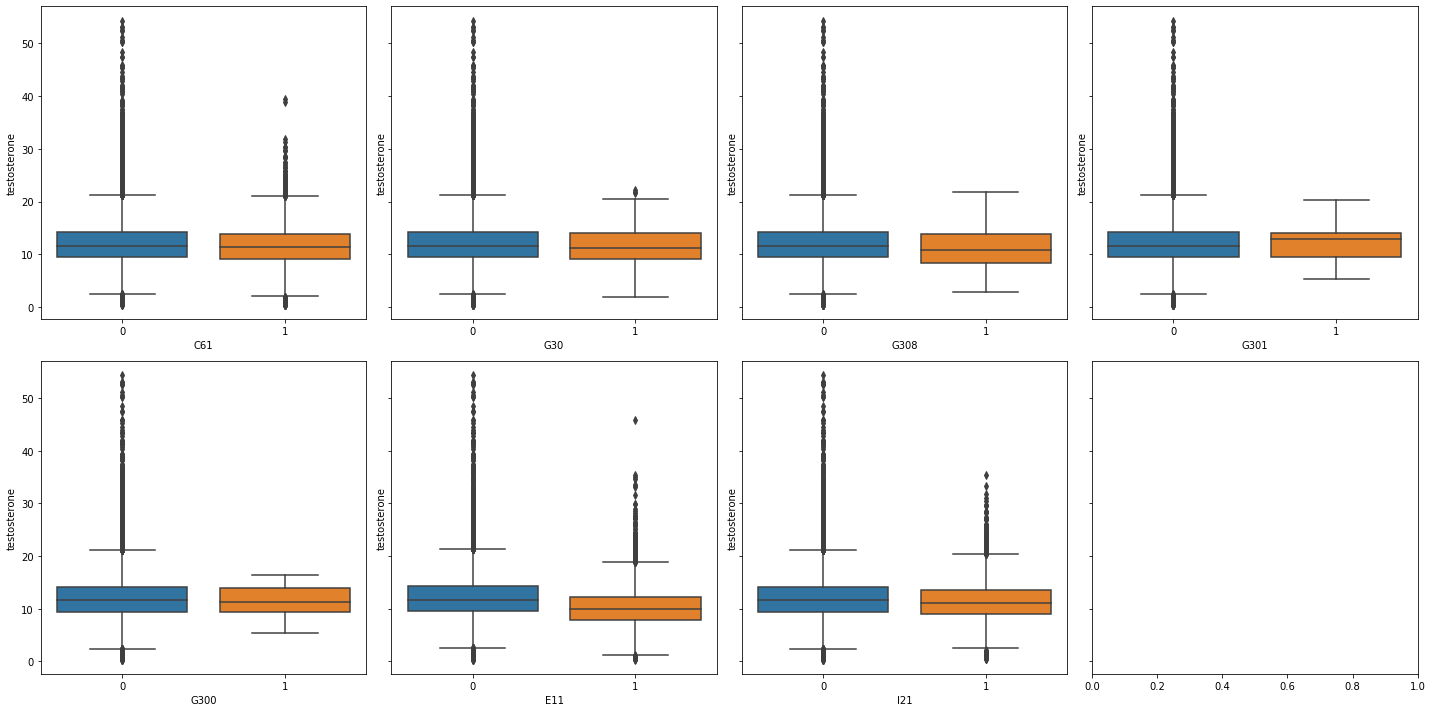

<Figure size 360x360 with 0 Axes>

<Figure size 360x360 with 0 Axes>

<Figure size 360x360 with 0 Axes>

<Figure size 360x360 with 0 Axes>

<Figure size 360x360 with 0 Axes>

<Figure size 360x360 with 0 Axes>

<Figure size 360x360 with 0 Axes>

In [111]:
fig, axs = plt.subplots(2, 4, sharey=True, tight_layout=True, figsize=(20, 10))
axli = axs.flatten()

for i,x in enumerate(prs.columns[4:11].tolist()):
    f=plt.figure(figsize=(5,5))
    sns.boxplot(x=x,y="testosterone",data=prs,ax=axli[i])

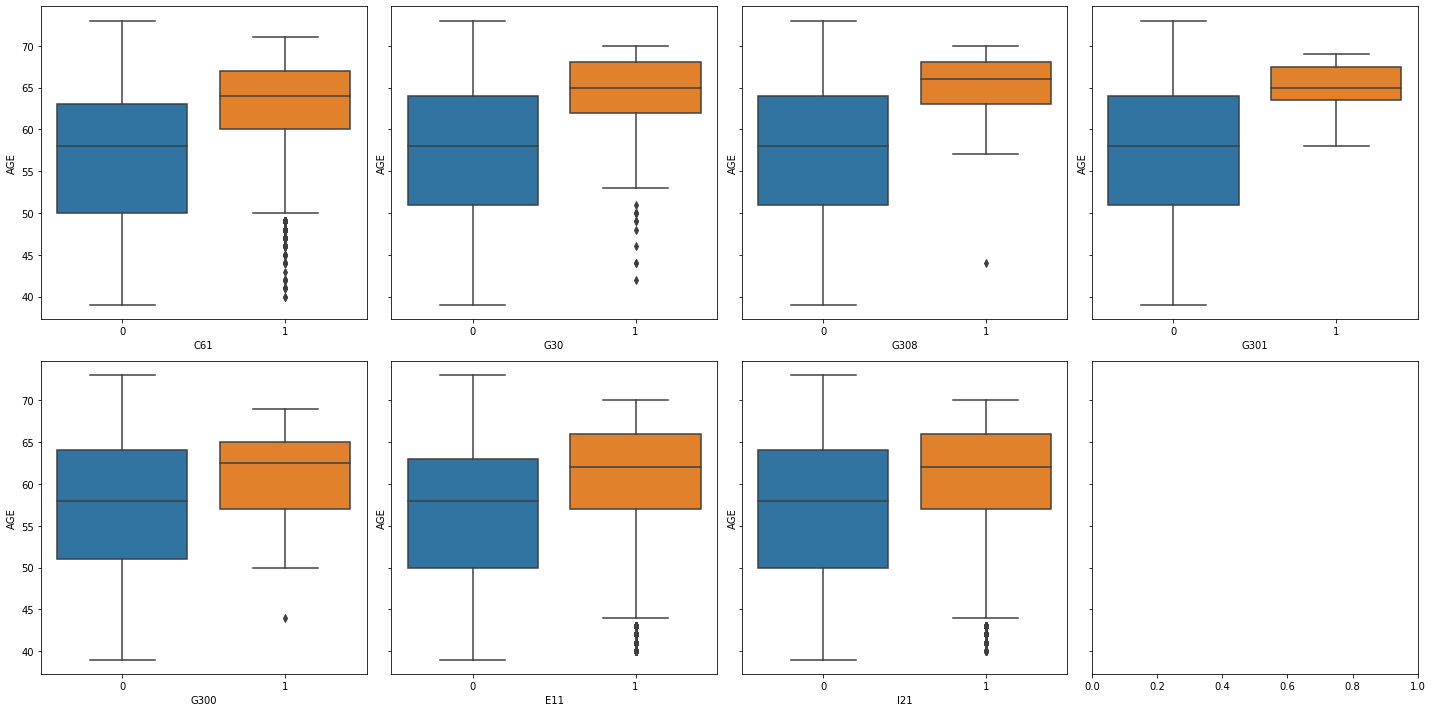

<Figure size 360x360 with 0 Axes>

<Figure size 360x360 with 0 Axes>

<Figure size 360x360 with 0 Axes>

<Figure size 360x360 with 0 Axes>

<Figure size 360x360 with 0 Axes>

<Figure size 360x360 with 0 Axes>

<Figure size 360x360 with 0 Axes>

In [112]:
fig, axs = plt.subplots(2, 4, sharey=True, tight_layout=True, figsize=(20, 10))
axli = axs.flatten()

for i,x in enumerate(prs.columns[4:11].tolist()):
    f=plt.figure(figsize=(5,5))
    sns.boxplot(x=x,y="AGE",data=prs,ax=axli[i])

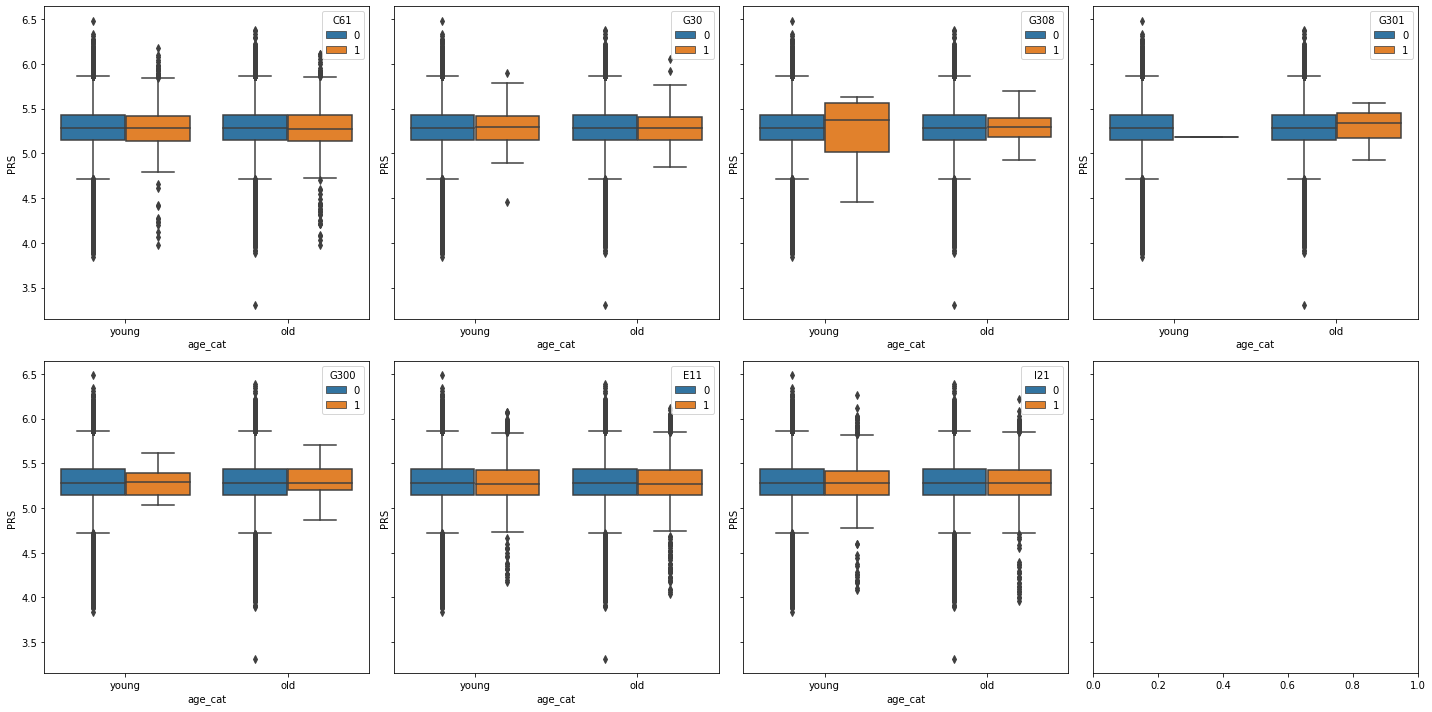

<Figure size 360x360 with 0 Axes>

<Figure size 360x360 with 0 Axes>

<Figure size 360x360 with 0 Axes>

<Figure size 360x360 with 0 Axes>

<Figure size 360x360 with 0 Axes>

<Figure size 360x360 with 0 Axes>

<Figure size 360x360 with 0 Axes>

In [113]:
fig, axs = plt.subplots(2, 4, sharey=True, tight_layout=True, figsize=(20, 10))
axli = axs.flatten()

for i,x in enumerate(prs.columns[4:11].tolist()):
    f=plt.figure(figsize=(5,5))
    sns.boxplot(x="age_cat",y="PRS",hue=x,data=prs,ax=axli[i])

### Get odds ratio of each quantile

In [114]:
#remove null age values
prs=prs[~prs["AGE"].isnull()]

In [115]:
    odds=pd.DataFrame()

    for i in range(10):
        for icd in prs.columns[4:11]:
            try:
                print(icd)
                quant.append(str(10*i))
                df_filt=prs[(prs["PRS"]>prs["PRS"].quantile(.1*i))&(prs["PRS"]<prs["PRS"].quantile(.1*(i+1)))]
                df_filt["PRS"]=zscore(df_filt["PRS"])
                print(df_filt.shape)
                print(df_filt[icd].value_counts())
                res=sm.Logit(df_filt[icd],df_filt[["PRS","AGE","PC1","PC2","PC3","PC4","PC5","PC6","PC7","PC8","PC9","PC10"]]).fit()
                params=np.exp(res.params)
                conf = np.exp(res.conf_int())
                conf['Odds Ratio'] = params
                conf.columns = ['5%', '95%', 'Odds Ratio']
                conf["icd"]=icd
                conf["quantile"]=str(10*i)
                odds=odds.append(conf)
            except:
                pass

        

C61
(17623, 26)
0    16918
1      705
Name: C61, dtype: int64
Optimization terminated successfully.
         Current function value: 0.184240
         Iterations 8
G30
(17623, 26)
0    17590
1       33
Name: G30, dtype: int64


/nrnb/opt/anaconda3.7/lib/python3.7/site-packages/ipykernel_launcher.py:9: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



Optimization terminated successfully.
         Current function value: 0.015558
         Iterations 12
G308
(17623, 26)
0    17619
1        4
Name: G308, dtype: int64
Optimization terminated successfully.
         Current function value: 0.002358
         Iterations 16
G301
(17623, 26)
0    17621
1        2
Name: G301, dtype: int64
Optimization terminated successfully.
         Current function value: 0.001125
         Iterations 18
G300
(17623, 26)
0    17619
1        4
Name: G300, dtype: int64
Optimization terminated successfully.
         Current function value: 0.002098
         Iterations 16
E11
(17623, 26)
0    16299
1     1324
Name: E11, dtype: int64
Optimization terminated successfully.
         Current function value: 0.283918
         Iterations 7
I21
(17623, 26)
0    16969
1      654
Name: I21, dtype: int64
Optimization terminated successfully.
         Current function value: 0.169514
         Iterations 8
C61
(17623, 26)
0    16916
1      707
Name: C61, dtype: int64
Optimi

In [116]:
odds["SE"]=odds["Odds Ratio"]-odds["5%"]
odds_prs=odds[odds.index=="PRS"]

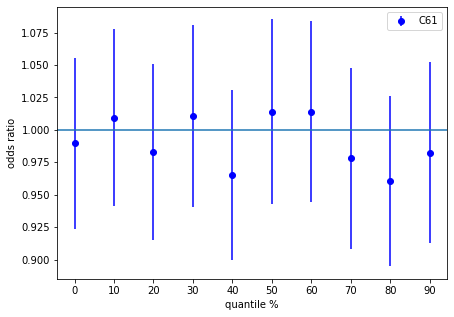

In [120]:

f=plt.figure(figsize=(7,5))

for icd in odds[odds["icd"]=="C61"]["icd"].unique():
    odds_plot=odds_prs[odds_prs["icd"]==icd]
    plt.errorbar(odds_plot["quantile"],odds_plot["Odds Ratio"],yerr=odds_plot["SE"],label=icd,fmt='o',color="blue")

plt.legend()
plt.xlabel("quantile %")
plt.ylabel("odds ratio")
plt.axhline(1)


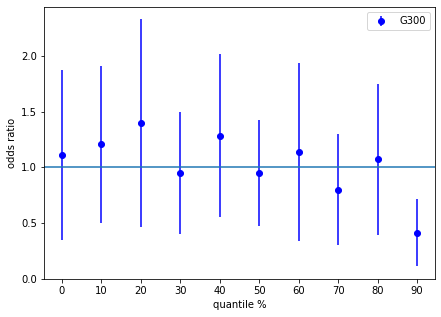

In [60]:

f=plt.figure(figsize=(7,5))

for icd in odds[odds["icd"]=="G300"]["icd"].unique():
    odds_plot=odds_prs[odds_prs["icd"]==icd]
    plt.errorbar(odds_plot["quantile"],odds_plot["Odds Ratio"],yerr=odds_plot["SE"],label=icd,fmt='o',color="blue")

plt.legend()
plt.xlabel("quantile %")
plt.ylabel("odds ratio")
plt.axhline(1)


### Conduct analyses by smoking status

In [76]:
smoking=pd.read_csv("../validation/ukbb.pheno.tsv",delimiter="\t")

In [77]:
mp=pd.read_csv("/nrnb/ukb-salem/GenoInfo/zUKBiobank_Salem_shared_ID_mapping_file.txt",delim_whitespace=True)
mp=dict(zip(mp["FID_Salem"],mp["FID"]))

In [78]:
smoking["FID"]=smoking["f.eid"].map(mp)

In [84]:
odds=pd.DataFrame()

for i in range(10):
    for icd in prs.columns[4:11]:
        for s in ["NEVER","CURRENT","PREVIOUS"]:
            try:
                print(s)
                print(icd)
                prs_smoking=prs[prs["FID"].isin(smoking[smoking["smoking"]==s]["FID"].tolist())]
                
                #get quantiles
                df_filt=prs_smoking[(prs_smoking["PRS"]>prs_smoking["PRS"].quantile(.1*i))&(prs_smoking["PRS"]<prs_smoking["PRS"].quantile(.1*(i+1)))]
                df_filt["PRS"]=zscore(df_filt["PRS"]) #zscore dataframe
                print(df_filt[icd].value_counts())
                
                #run logodds analysis
                res=sm.Logit(df_filt[icd],df_filt[["PRS","AGE","PC1","PC2","PC3","PC4","PC5","PC6","PC7","PC8","PC9","PC10"]]).fit()
                params=np.exp(res.params)
                conf = np.exp(res.conf_int())
                conf['Odds Ratio'] = params
                conf.columns = ['5%', '95%', 'Odds Ratio']
                conf["icd"]=icd
                conf["smoking"]=s
                conf["quantile"]=str(10*i)
                odds=odds.append(conf)
            except:
                pass

NEVER
C61
0    8214
1     314
Name: C61, dtype: int64


/nrnb/opt/anaconda3.7/lib/python3.7/site-packages/ipykernel_launcher.py:13: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



Optimization terminated successfully.
         Current function value: 0.174935
         Iterations 8
CURRENT
C61
0    2064
1      71
Name: C61, dtype: int64
Optimization terminated successfully.
         Current function value: 0.158361
         Iterations 9
PREVIOUS
C61
0    6567
1     318
Name: C61, dtype: int64
Optimization terminated successfully.
         Current function value: 0.200044
         Iterations 8
NEVER
G30
0    8512
1      16
Name: G30, dtype: int64
Optimization terminated successfully.
         Current function value: 0.015707
         Iterations 12
CURRENT
G30
0    2132
1       3
Name: G30, dtype: int64
Optimization terminated successfully.
         Current function value: 0.011874
         Iterations 12
PREVIOUS
G30
0    6871
1      14
Name: G30, dtype: int64
Optimization terminated successfully.
         Current function value: 0.016158
         Iterations 12
NEVER
G308
0    8527
1       1
Name: G308, dtype: int64
Optimization terminated successfully.
         Cu

/nrnb/opt/anaconda3.7/lib/python3.7/site-packages/ipykernel_launcher.py:19: RuntimeWarning:

overflow encountered in exp



0    6885
1       1
Name: G301, dtype: int64
Optimization terminated successfully.
         Current function value: 0.000768
         Iterations 24
NEVER
G300
0    8527
1       2
Name: G300, dtype: int64
Optimization terminated successfully.
         Current function value: 0.001775
         Iterations 17
CURRENT
G300
0    2136
Name: G300, dtype: int64
PREVIOUS
G300
0    6885
1       1
Name: G300, dtype: int64
         Current function value: inf
         Iterations: 35
NEVER
E11


/nrnb/opt/anaconda3.7/lib/python3.7/site-packages/statsmodels/discrete/discrete_model.py:1747: RuntimeWarning:

overflow encountered in exp

/nrnb/opt/anaconda3.7/lib/python3.7/site-packages/statsmodels/discrete/discrete_model.py:1800: RuntimeWarning:

divide by zero encountered in log



0    8141
1     388
Name: E11, dtype: int64
Optimization terminated successfully.
         Current function value: 0.198077
         Iterations 8
CURRENT
E11
0    1946
1     190
Name: E11, dtype: int64
Optimization terminated successfully.
         Current function value: 0.313572
         Iterations 7
PREVIOUS
E11
0    6201
1     685
Name: E11, dtype: int64
Optimization terminated successfully.
         Current function value: 0.338128
         Iterations 6
NEVER
I21
0    8294
1     235
Name: I21, dtype: int64
Optimization terminated successfully.
         Current function value: 0.137110
         Iterations 9
CURRENT
I21
0    2017
1     119
Name: I21, dtype: int64
Optimization terminated successfully.
         Current function value: 0.224027
         Iterations 8
PREVIOUS
I21
0    6579
1     307
Name: I21, dtype: int64
Optimization terminated successfully.
         Current function value: 0.190020
         Iterations 8
NEVER
C61
0    8218
1     310
Name: C61, dtype: int64
Optimizati

In [89]:
odds["SE"]=odds["Odds Ratio"]-odds["5%"]
odds_prs=odds[odds.index=="PRS"]

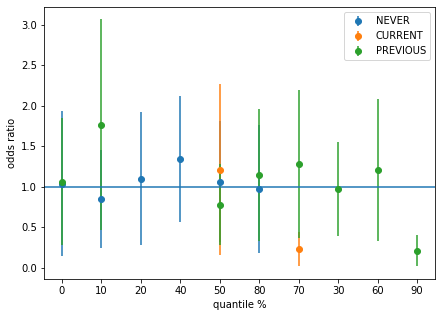

In [92]:

f=plt.figure(figsize=(7,5))

for icd in odds[odds["icd"]=="G300"]["icd"].unique():
    for s in ["NEVER","CURRENT","PREVIOUS"]:
        odds_plot=odds_prs[(odds_prs["icd"]==icd)&(odds_prs["smoking"]==s)]
        plt.errorbar(odds_plot["quantile"],odds_plot["Odds Ratio"],yerr=odds_plot["SE"],label=s,fmt='o')

plt.legend()
plt.xlabel("quantile %")
plt.ylabel("odds ratio")
plt.axhline(1)


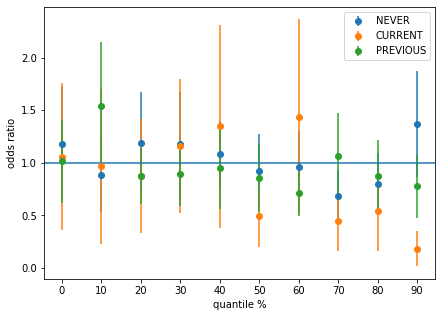

In [93]:

f=plt.figure(figsize=(7,5))

for icd in odds[odds["icd"]=="G30"]["icd"].unique():
    for s in ["NEVER","CURRENT","PREVIOUS"]:
        odds_plot=odds_prs[(odds_prs["icd"]==icd)&(odds_prs["smoking"]==s)]
        plt.errorbar(odds_plot["quantile"],odds_plot["Odds Ratio"],yerr=odds_plot["SE"],label=s,fmt='o')

plt.legend()
plt.xlabel("quantile %")
plt.ylabel("odds ratio")
plt.axhline(1)


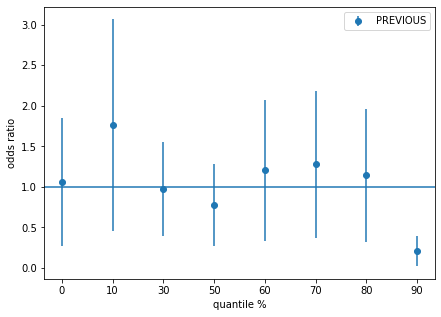

In [94]:

f=plt.figure(figsize=(7,5))

for icd in odds[odds["icd"]=="G300"]["icd"].unique():
    for s in ["PREVIOUS"]:
        odds_plot=odds_prs[(odds_prs["icd"]==icd)&(odds_prs["smoking"]==s)]
        plt.errorbar(odds_plot["quantile"],odds_plot["Odds Ratio"],yerr=odds_plot["SE"],label=s,fmt='o')

plt.legend()
plt.xlabel("quantile %")
plt.ylabel("odds ratio")
plt.axhline(1)


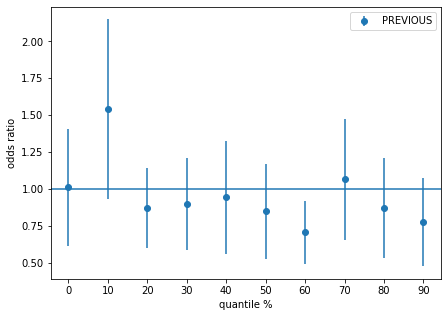

In [95]:

f=plt.figure(figsize=(7,5))

for icd in odds[odds["icd"]=="G30"]["icd"].unique():
    for s in ["PREVIOUS"]:
        odds_plot=odds_prs[(odds_prs["icd"]==icd)&(odds_prs["smoking"]==s)]
        plt.errorbar(odds_plot["quantile"],odds_plot["Odds Ratio"],yerr=odds_plot["SE"],label=s,fmt='o')

plt.legend()
plt.xlabel("quantile %")
plt.ylabel("odds ratio")
plt.axhline(1)


In [123]:
smoking[smoking["FID"].isin(prs["FID"].tolist())]["smoking"].value_counts()

NEVER       85285
PREVIOUS    68855
CURRENT     21359
Name: smoking, dtype: int64

### Run odds ratios for young population

In [179]:
prs_young=prs[prs["AGE"]<70]

In [180]:
odds=pd.DataFrame()

for icd in prs_young.columns[4:11]:
    for i in range(10):
        try:
            print(icd)
            print("quantile {}".format(i*10))
            df_filt=prs_young[(prs_young["PRS"]>prs_young["PRS"].quantile(.1*i))&(prs_young["PRS"]<prs_young["PRS"].quantile(.1*(i+1)))]
            df_filt["PRS"]=zscore(df_filt["PRS"])
            print(df_filt.shape)
            print(df_filt[icd].value_counts())
            res=sm.Logit(df_filt[icd],df_filt[["PRS","AGE","PC1","PC2","PC3","PC4","PC5","PC6","PC7","PC8","PC9","PC10"]]).fit()
            params=np.exp(res.params)
            conf = np.exp(res.conf_int())
            conf['Odds Ratio'] = params
            conf.columns = ['5%', '95%', 'Odds Ratio']
            conf["icd"]=icd
            conf["quantile"]=str(10*i)
            odds=odds.append(conf)
        except:
            print(i,icd)
        

C61
quantile 0
(17529, 25)
0    16835
1      694
Name: C61, dtype: int64
Optimization terminated successfully.
         Current function value: 0.182740
         Iterations 8
C61
quantile 10
(17529, 25)
0    16831
1      698
Name: C61, dtype: int64


/nrnb/opt/anaconda3.7/lib/python3.7/site-packages/ipykernel_launcher.py:9: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



Optimization terminated successfully.
         Current function value: 0.183923
         Iterations 8
C61
quantile 20
(17530, 25)
0    16863
1      667
Name: C61, dtype: int64
Optimization terminated successfully.
         Current function value: 0.177173
         Iterations 8
C61
quantile 30
(17529, 25)
0    16868
1      661
Name: C61, dtype: int64
Optimization terminated successfully.
         Current function value: 0.177355
         Iterations 8
C61
quantile 40
(17529, 25)
0    16833
1      696
Name: C61, dtype: int64
Optimization terminated successfully.
         Current function value: 0.183766
         Iterations 7
C61
quantile 50
(17529, 25)
0    16883
1      646
Name: C61, dtype: int64
Optimization terminated successfully.
         Current function value: 0.173232
         Iterations 8
C61
quantile 60
(17529, 25)
0    16858
1      671
Name: C61, dtype: int64
Optimization terminated successfully.
         Current function value: 0.177645
         Iterations 8
C61
quantile 70
(1

In [184]:
odds["SE"]=odds["Odds Ratio"]-odds["5%"]
odds_prs=odds[odds.index=="PRS"]

In [185]:
odds_prs

,5%,95%,Odds Ratio,icd,quantile,SE
PRS,0.919293,1.055067,0.984843,C61,0,0.065550
PRS,0.940436,1.083281,1.009335,C61,10,0.068899
PRS,0.916075,1.058391,0.984665,C61,20,0.068590
PRS,0.940053,1.086298,1.010534,C61,30,0.070481
PRS,0.897367,1.033492,0.963027,C61,40,0.065660
...,...,...,...,...,...,...
PRS,0.912523,1.057614,0.982394,I21,50,0.069871
PRS,0.874330,1.008162,0.938865,I21,60,0.064534
PRS,0.933273,1.081442,1.004630,I21,70,0.071356
PRS,0.862565,1.005232,0.931170,I21,80,0.068605


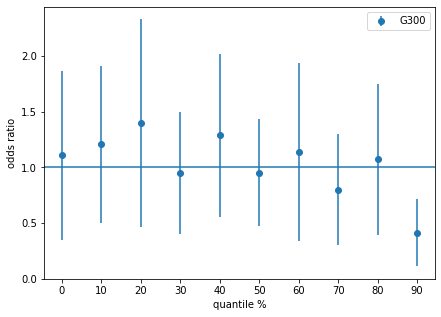

In [183]:

f=plt.figure(figsize=(7,5))

for icd in odds[odds["icd"]==("G300")]["icd"].unique():
    odds_plot=odds_prs[odds_prs["icd"]==icd]
    plt.errorbar(odds_plot["quantile"],odds_plot["Odds Ratio"],yerr=odds_plot["SE"],label=icd,fmt='o')

plt.legend()
plt.xlabel("quantile %")
plt.ylabel("odds ratio")
plt.axhline(1)


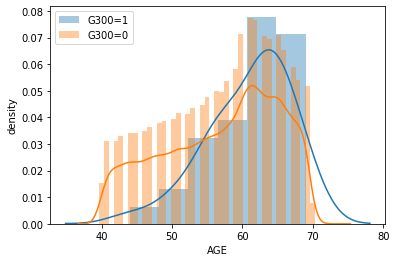

In [106]:
sns.distplot(prs[prs["G300"]==1]["AGE"].tolist(),label="G300=1")
sns.distplot(prs[prs["G300"]==0]["AGE"].tolist(),label="G300=0")
plt.ylabel("density")
plt.xlabel("AGE")
plt.legend()

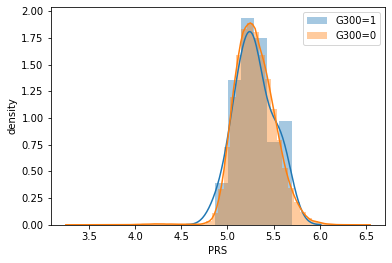

In [110]:
sns.distplot(prs[prs["G300"]==1]["PRS"].tolist(),label="G300=1")
sns.distplot(prs[prs["G300"]==0]["PRS"].tolist(),label="G300=0")
plt.ylabel("density")
plt.xlabel("PRS")
plt.legend()

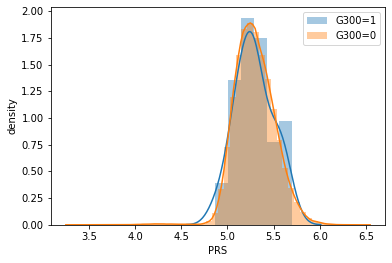

In [111]:
sns.distplot(prs[(prs["G300"]==1)&(prs["AGE"]<70)]["PRS"].tolist(),label="G300=1")
sns.distplot(prs[(prs["G300"]==0)&(prs["AGE"]<70)]["PRS"].tolist(),label="G300=0")
plt.ylabel("density")
plt.xlabel("PRS")
plt.legend()

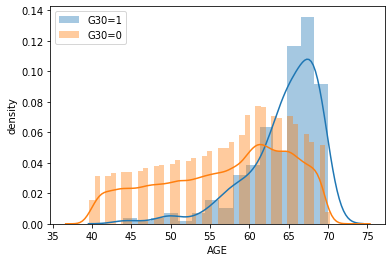

In [113]:
sns.distplot(prs[prs["G30"]==1]["AGE"].tolist(),label="G30=1")
sns.distplot(prs[prs["G30"]==0]["AGE"].tolist(),label="G30=0")
plt.ylabel("density")
plt.xlabel("AGE")
plt.legend()

In [53]:
prs_young[prs_young["G300"]==1]["PRS"].median()

4.861073062752

In [54]:
prs_young[prs_young["G300"]==0]["PRS"].median()

4.90939854764

In [224]:
odds["Odds Ratio"]-odds["95%"]

PRS   -0.008521
PRS   -0.018857
PRS   -0.031126
PRS   -0.064621
PRS   -0.036089
         ...   
PRS   -0.046595
PRS   -0.046602
PRS   -0.038541
PRS   -0.007153
PRS   -0.008545
Length: 70, dtype: float64

In [139]:
from sklearn.linear_model import LogisticRegression

In [140]:
clf = LogisticRegression(C=1e5)

In [158]:
clf.fit(np.array(prs[["PRS","testosterone"]]),prs["C61"])

LogisticRegression(C=100000.0, class_weight=None, dual=False,
                   fit_intercept=True, intercept_scaling=1, l1_ratio=None,
                   max_iter=100, multi_class='auto', n_jobs=None, penalty='l2',
                   random_state=None, solver='lbfgs', tol=0.0001, verbose=0,
                   warm_start=False)

In [162]:
prs["C61_map"]=prs["C61"].map({2:1,1:0})

In [188]:
res=sm.Logit(prs["C61_map"],prs[["PRS","testosterone"]]).fit()

Optimization terminated successfully.
         Current function value: 0.160371
         Iterations 7


In [189]:
res=sm.Logit(prs["C61_map"],prs["PRS"]).fit()

Optimization terminated successfully.
         Current function value: 0.160622
         Iterations 7


In [190]:
params=np.exp(res.params)

In [191]:
conf = np.exp(res.conf_int())

In [192]:
conf['Odds Ratio'] = params

In [193]:
conf.columns = ['5%', '95%', 'Odds Ratio']

In [194]:
conf

,5%,95%,Odds Ratio
PRS,0.514582,0.519896,0.517232


In [173]:
res.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                C61_map   No. Observations:               166502
Model:                          Logit   Df Residuals:                   166500
Method:                           MLE   Df Model:                            1
Date:                Wed, 09 Jun 2021   Pseudo R-squ.:                0.001067
Time:                        10:43:43   Log-Likelihood:                -26702.
converged:                       True   LL-Null:                       -26731.
Covariance Type:            nonrobust   LLR p-value:                 4.321e-14
================================================================================
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
PRS             -0.5804      0.009    -64.515      0.000      -0.598      -0.563
testosterone    -0.0330      0.004     -9.015      0.000      -0.040      -0.026
================================================================================
"""

In [154]:
clf.

In [64]:
os.listdir("../prs/OptunaResults/sampling/LogReg/")

['LogRegOptunisticInfection_C61.LogReg.pkl',
 'LogRegOptunisticInfection_G30.LogReg.pkl',
 'LogRegOptunisticInfection_G300.LogReg.pkl',
 'LogRegOptunisticInfection_G301.LogReg.pkl',
 'LogRegOptunisticInfection_E11.LogReg.pkl',
 'LogRegOptunisticInfection_G308.LogReg.pkl']

C61
number                                                    423
value                                                0.548952
datetime_start                     2021-05-26 05:07:36.882847
datetime_complete                  2021-05-26 05:07:37.777157
duration                               0 days 00:00:00.894310
params_LogReg_ElasticNetL1Ratio                      0.245423
params_LogReg_Regularization                                1
params_LogReg_penaltyfx                            elasticnet
params_RF_bootstrap                                       NaN
params_RF_min_samples_leaf                                NaN
params_RF_min_samples_split                               NaN
params_RF_n_estimators                                    NaN
params_SVM_Degree                                         NaN
params_SVM_GammaMethod                                    NaN
params_SVM_Gamma_Number                                   NaN
params_SVM_Regularization                                 NaN
para

/nrnb/opt/anaconda3.7/lib/python3.7/site-packages/sklearn/linear_model/_logistic.py:970: RuntimeWarning:

divide by zero encountered in double_scalars

/nrnb/opt/anaconda3.7/lib/python3.7/site-packages/sklearn/linear_model/_logistic.py:971: RuntimeWarning:

divide by zero encountered in double_scalars

/nrnb/opt/anaconda3.7/lib/python3.7/site-packages/sklearn/linear_model/_sag.py:306: RuntimeWarning:

invalid value encountered in double_scalars



LogRegOptunisticInfection_G30.LogReg.pkl
G300
number                                                    254
value                                                    0.75
datetime_start                     2021-05-26 01:28:15.189937
datetime_complete                  2021-05-26 01:28:16.104131
duration                               0 days 00:00:00.914194
params_LogReg_ElasticNetL1Ratio                      0.248433
params_LogReg_Regularization                                4
params_LogReg_penaltyfx                            elasticnet
params_RF_bootstrap                                       NaN
params_RF_min_samples_leaf                                NaN
params_RF_min_samples_split                               NaN
params_RF_n_estimators                                    NaN
params_SVM_Degree                                         NaN
params_SVM_GammaMethod                                    NaN
params_SVM_Gamma_Number                                   NaN
params_SVM_Regularizatio

/nrnb/opt/anaconda3.7/lib/python3.7/site-packages/sklearn/linear_model/_logistic.py:1501: UserWarning:

l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)



E11
number                                                     32
value                                                0.521777
datetime_start                     2021-05-26 01:47:29.490958
datetime_complete                  2021-05-26 01:47:30.192195
duration                               0 days 00:00:00.701237
params_LogReg_ElasticNetL1Ratio                      0.204311
params_LogReg_Regularization                                2
params_LogReg_penaltyfx                            elasticnet
params_RF_bootstrap                                       NaN
params_RF_min_samples_leaf                                NaN
params_RF_min_samples_split                               NaN
params_RF_n_estimators                                    NaN
params_SVM_Degree                                         NaN
params_SVM_GammaMethod                                    NaN
params_SVM_Gamma_Number                                   NaN
params_SVM_Regularization                                 NaN
para

/nrnb/opt/anaconda3.7/lib/python3.7/site-packages/sklearn/linear_model/_logistic.py:1501: UserWarning:

l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)



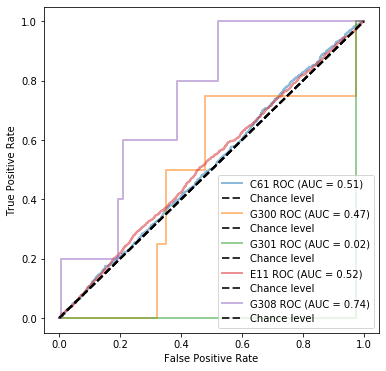

In [100]:
for icd in os.listdir("../prs/OptunaResults/sampling/LogReg/"):
    try:
        icd_code=icd.split("_")[1].split(".")[0]
        print(icd_code)
    
        study = joblib.load("../prs/OptunaResults/sampling/LogReg/LogRegOptunisticInfection_"+icd_code+".LogReg.pkl")
        study_df = study.trials_dataframe()
        study_df=study_df[study_df["params_modelType"]=="LogReg"]
        study_best=study_df.sort_values(by="value").iloc[-1,:]
    
        print(study_best)
    
        model = linear_model.LogisticRegression(penalty = study_best["params_LogReg_penaltyfx"], solver = "saga", C=study_best["params_LogReg_Regularization"], l1_ratio = study_best["params_LogReg_ElasticNetL1Ratio"], random_state = 331)
    
        prs=pd.read_csv("eur.test.prs.tsv",delimiter="\t")
        train=pd.read_csv("eur.test.train.prs.tsv",delimiter="\t")
        prs["PRS"]=zscore(prs["PRS"])
        prs_test=prs[~prs["FID"].isin(train["FID"].tolist())]
        prs_train=prs[prs["FID"].isin(train["FID"].tolist())]
    
        all_probs=model.fit(np.array(prs_train["PRS"]).reshape(-1, 1), np.ravel(np.array(prs_train[icd_code]).reshape(-1, 1))).predict_proba(np.array(prs_test["PRS"]).reshape(-1, 1))[:,1]
    
        fpr,tpr,_ = roc_curve(prs_test[icd_code].tolist(),all_probs,pos_label=2)
        rocketPower = roc_auc_score(prs_test[icd_code].tolist(), all_probs)
        lw = 2.3
#         plt.plot([0, 1], [0, 1], 'k--', lw=lw)
#         plt.plot(fpr,tpr, color = 'red', label = "AUC = {0:0.5f}".format(rocketPower)) #PC ROC curve (area = {0:0.5f})
#         print(rocketPower)
#         plt.xlabel("False Positive Rate", fontsize = 17)
#         plt.ylabel("True Positive Rate", fontsize = 17)
        plt.figure(1, figsize=(6,6))
        plt.plot(fpr, tpr, lw=2, alpha=0.5, label=icd_code+' ROC (AUC = %0.2f)' % (rocketPower))
        plt.plot([0, 1], [0, 1], linestyle='--', lw=2, color='k', label='Chance level', alpha=.8)
        plt.xlim([-0.05, 1.05])
        plt.ylim([-0.05, 1.05])
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.legend(loc="lower right")
    
    except:
        print(icd)

G300
number                                                     31
value                                                0.833333
datetime_start                     2021-05-26 01:27:25.748378
datetime_complete                  2021-05-26 01:27:27.181666
duration                               0 days 00:00:01.433288
params_LogReg_ElasticNetL1Ratio                           NaN
params_LogReg_Regularization                              NaN
params_LogReg_penaltyfx                                   NaN
params_RF_bootstrap                                     False
params_RF_min_samples_leaf                                  5
params_RF_min_samples_split                                10
params_RF_n_estimators                                     92
params_SVM_Degree                                         NaN
params_SVM_GammaMethod                                    NaN
params_SVM_Gamma_Number                                   NaN
params_SVM_Regularization                                 NaN
par

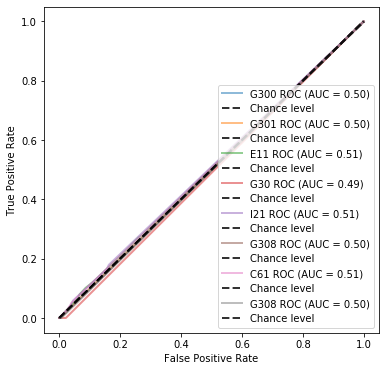

In [114]:
    for icd in os.listdir("../prs/OptunaResults/sampling/RandomForest/"):
#     try:
        icd_code=icd.split("_")[1].split(".")[0]
        print(icd_code)
    
        study = joblib.load("../prs/OptunaResults/sampling/RandomForest/RandomForestOptunisticInfection_"+icd_code+".RandomForest.pkl")
        study_df = study.trials_dataframe()
        study_df=study_df[study_df["params_modelType"]=="RandomForest"]
        study_best=study_df.sort_values(by="value").iloc[-1,:]
    
        print(study_best)
    
        model = RandomForestClassifier(n_estimators=int(study_best["params_RF_n_estimators"]), bootstrap=study_best["params_RF_bootstrap"], min_samples_split=int(study_best["params_RF_min_samples_split"]), min_samples_leaf=int(study_best["params_RF_min_samples_leaf"]), random_state = 331)
    
        prs=pd.read_csv("eur.test.prs.tsv",delimiter="\t")
        train=pd.read_csv("eur.test.train.prs.tsv",delimiter="\t")
        prs["PRS"]=zscore(prs["PRS"])
        prs_test=prs[~prs["FID"].isin(train["FID"].tolist())]
        prs_train=prs[prs["FID"].isin(train["FID"].tolist())]
    
        all_probs=model.fit(np.array(prs_train["PRS"]).reshape(-1, 1), np.ravel(np.array(prs_train[icd_code]).reshape(-1, 1))).predict_proba(np.array(prs_test["PRS"]).reshape(-1, 1))[:,1]
    
        fpr,tpr,_ = roc_curve(prs_test[icd_code].tolist(),all_probs,pos_label=2)
        rocketPower = roc_auc_score(prs_test[icd_code].tolist(), all_probs)
        lw = 2.3

        plt.figure(1, figsize=(6,6))
        plt.plot(fpr, tpr, lw=2, alpha=0.5, label=icd_code+' ROC (AUC = %0.2f)' % (rocketPower))
        plt.plot([0, 1], [0, 1], linestyle='--', lw=2, color='k', label='Chance level', alpha=.8)
        plt.xlim([-0.05, 1.05])
        plt.ylim([-0.05, 1.05])
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.legend(loc="lower right")
    
#     except:
#         print(icd)

G300
number                                                    500
value                                                       1
datetime_start                     2021-05-26 01:29:24.971896
datetime_complete                  2021-05-26 01:29:25.779935
duration                               0 days 00:00:00.808039
params_LogReg_ElasticNetL1Ratio                           NaN
params_LogReg_Regularization                              NaN
params_LogReg_penaltyfx                                   NaN
params_RF_bootstrap                                       NaN
params_RF_min_samples_leaf                                NaN
params_RF_min_samples_split                               NaN
params_RF_n_estimators                                    NaN
params_SVM_Degree                                           3
params_SVM_GammaMethod                                 number
params_SVM_Gamma_Number                               393.849
params_SVM_Regularization                                  -2
par

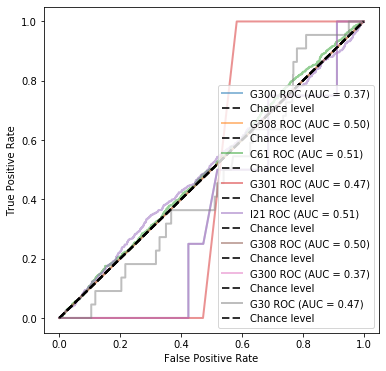

In [121]:
    for icd in os.listdir("../prs/OptunaResults/sampling/SVM/"):
#     try:
        icd_code=icd.split("_")[1].split(".")[0]
        print(icd_code)
    
        study = joblib.load("../prs/OptunaResults/sampling/SVM/SVMOptunisticInfection_"+icd_code+".SVM.pkl")
        study_df = study.trials_dataframe()
        study_df=study_df[study_df["params_modelType"]=="SVM"]
        study_best=study_df.sort_values(by="value").iloc[-1,:]
    
        print(study_best)
    
        model = SVC(kernel=study_best["params_SVM_kernel"],probability=True, C = (10**study_best["params_SVM_Regularization"]), gamma = study_best["params_SVM_Gamma_Number"], degree = study_best["params_SVM_Degree"], random_state = 331)
    
        prs=pd.read_csv("eur.test.prs.tsv",delimiter="\t")
        train=pd.read_csv("eur.test.train.prs.tsv",delimiter="\t")
        prs["PRS"]=zscore(prs["PRS"])
        prs_test=prs[~prs["FID"].isin(train["FID"].tolist())]
        prs_train=prs[prs["FID"].isin(train["FID"].tolist())]
    
        all_probs=model.fit(np.array(prs_train["PRS"]).reshape(-1, 1), np.ravel(np.array(prs_train[icd_code]).reshape(-1, 1))).predict_proba(np.array(prs_test["PRS"]).reshape(-1, 1))[:,1]
    
        fpr,tpr,_ = roc_curve(prs_test[icd_code].tolist(),all_probs,pos_label=2)
        rocketPower = roc_auc_score(prs_test[icd_code].tolist(), all_probs)
        lw = 2.3

        plt.figure(1, figsize=(6,6))
        plt.plot(fpr, tpr, lw=2, alpha=0.5, label=icd_code+' ROC (AUC = %0.2f)' % (rocketPower))
        plt.plot([0, 1], [0, 1], linestyle='--', lw=2, color='k', label='Chance level', alpha=.8)
        plt.xlim([-0.05, 1.05])
        plt.ylim([-0.05, 1.05])
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.legend(loc="lower right")
    
#     except:
#         print(icd)

In [115]:
study = joblib.load("../prs/OptunaResults/sampling/SVM/SVMOptunisticInfection_C61.SVM.pkl")
study_df = study.trials_dataframe()

In [118]:
study_df[study_df["params_modelType"]=="SVM"].loc[0]

number                                                      0
value                                                     0.5
datetime_start                     2021-05-26 01:27:00.471694
datetime_complete                  2021-05-26 01:27:58.807541
duration                               0 days 00:00:58.335847
params_LogReg_ElasticNetL1Ratio                           NaN
params_LogReg_Regularization                              NaN
params_LogReg_penaltyfx                                   NaN
params_RF_bootstrap                                       NaN
params_RF_min_samples_leaf                                NaN
params_RF_min_samples_split                               NaN
params_RF_n_estimators                                    NaN
params_SVM_Degree                                           4
params_SVM_GammaMethod                                   auto
params_SVM_Gamma_Number                                   NaN
params_SVM_Regularization                                  -3
params_S

In [86]:
        study = joblib.load("../prs/OptunaResults/sampling/LogReg/LogRegOptunisticInfection_G30.LogReg.pkl")
        study_df = study.trials_dataframe()
        study_best=study_df.sort_values(by="value").iloc[-1,:]

In [90]:
        model = linear_model.LogisticRegression(penalty = study_best["params_LogReg_penaltyfx"], solver = "saga", C=study_best["params_LogReg_Regularization"], l1_ratio = study_best["params_LogReg_ElasticNetL1Ratio"], random_state = 331)
    
        prs=pd.read_csv("eur.test.prs.tsv",delimiter="\t")
        train=pd.read_csv("eur.test.train.prs.tsv",delimiter="\t")
        prs["PRS"]=zscore(prs["PRS"])
        prs_test=prs[~prs["FID"].isin(train["FID"].tolist())]
        prs_train=prs[prs["FID"].isin(train["FID"].tolist())]
    
        all_probs=model.fit(np.array(prs_train["PRS"]).reshape(-1, 1), np.ravel(np.array(prs_train["G30"]).reshape(-1, 1))).predict_proba(np.array(prs_test["PRS"]).reshape(-1, 1))[:,1]

ValueError: Logistic Regression supports only penalties in ['l1', 'l2', 'elasticnet', 'none'], got nan.

In [95]:
study_df[study_df["params_modelType"]=="LogReg"].sort_values(by="value")

,number,value,datetime_start,datetime_complete,duration,params_LogReg_ElasticNetL1Ratio,params_LogReg_Regularization,params_LogReg_penaltyfx,params_RF_bootstrap,params_RF_min_samples_leaf,params_RF_min_samples_split,params_RF_n_estimators,params_SVM_Degree,params_SVM_GammaMethod,params_SVM_Gamma_Number,params_SVM_Regularization,params_SVM_kernel,params_modelType,state
24,24,0.482127,2021-05-26 01:40:13.782646,2021-05-26 01:40:14.645419,00:00:00.862773,0.504038,5.0,elasticnet,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,LogReg,COMPLETE
35,35,0.494754,2021-05-26 01:48:26.059033,2021-05-26 01:48:26.696766,00:00:00.637733,0.298730,3.0,elasticnet,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,LogReg,COMPLETE
36,36,0.497241,2021-05-26 01:48:26.714668,2021-05-26 01:48:27.790871,00:00:01.076203,0.606755,1.0,elasticnet,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,LogReg,COMPLETE
33,33,0.497308,2021-05-26 01:47:30.193948,2021-05-26 01:47:30.962865,00:00:00.768917,0.004907,1.0,elasticnet,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,LogReg,COMPLETE
272,272,0.497600,2021-05-26 13:27:51.571218,2021-05-26 13:27:52.276943,00:00:00.705725,0.314514,-2.0,l1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,LogReg,COMPLETE
300,300,0.499696,2021-05-26 13:37:19.401224,2021-05-26 13:37:20.228268,00:00:00.827044,0.910814,-1.0,l2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,LogReg,COMPLETE
0,0,0.500000,2021-05-26 01:27:00.460999,2021-05-26 01:27:01.988137,00:00:01.527138,0.845589,-4.0,l1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,LogReg,COMPLETE
182,182,0.500000,2021-05-26 12:43:58.939024,2021-05-26 12:43:59.688532,00:00:00.749508,0.439645,-5.0,elasticnet,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,LogReg,COMPLETE
230,230,0.500000,2021-05-26 13:03:31.075434,2021-05-26 13:03:31.751529,00:00:00.676095,0.857883,-3.0,l1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,LogReg,COMPLETE
316,316,0.500000,2021-05-26 13:42:10.903318,2021-05-26 13:42:11.708060,00:00:00.804742,0.684640,-4.0,elasticnet,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,LogReg,COMPLETE


In [85]:
prs_train["G30"].value_counts()

1    149546
2       305
Name: G30, dtype: int64

In [11]:
best

number                                                    423
value                                                0.548952
datetime_start                     2021-05-26 05:07:36.882847
datetime_complete                  2021-05-26 05:07:37.777157
duration                               0 days 00:00:00.894310
params_LogReg_ElasticNetL1Ratio                      0.245423
params_LogReg_Regularization                                1
params_LogReg_penaltyfx                            elasticnet
params_RF_bootstrap                                       NaN
params_RF_min_samples_leaf                                NaN
params_RF_min_samples_split                               NaN
params_RF_n_estimators                                    NaN
params_SVM_Degree                                         NaN
params_SVM_GammaMethod                                    NaN
params_SVM_Gamma_Number                                   NaN
params_SVM_Regularization                                 NaN
params_S

In [26]:
model = linear_model.LogisticRegression(penalty = best["params_LogReg_penaltyfx"], solver = "saga", C=best["params_LogReg_Regularization"], l1_ratio = best["params_LogReg_ElasticNetL1Ratio"], random_state = 331, class_weight="balanced")

In [18]:
prs=pd.read_csv("eur.test.prs.tsv",delimiter="\t")

In [30]:
prs

,FID,PRS,testosterone,IID,C61,G30,G308,G301,G300,E11,I21
0,1243037,5.138125,8.846,1243037,1,1,1,1,1,1,1
1,3581610,4.964683,9.935,3581610,1,1,1,1,1,1,1
2,5518499,5.069086,11.004,5518499,1,1,1,1,1,1,1
3,1447072,4.942110,14.753,1447072,1,1,1,1,1,1,1
4,3472607,4.966854,10.198,3472607,1,1,1,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...
166497,3869794,4.716445,9.945,3869794,1,1,1,1,1,1,1
166498,3386064,5.200511,15.108,3386064,2,1,1,1,1,1,1
166499,2472951,5.028627,15.518,2472951,1,1,1,1,1,1,1
166500,4639336,4.819319,9.007,4639336,1,1,1,1,1,1,1


In [31]:
train=pd.read_csv("eur.test.train.prs.tsv",delimiter="\t")

In [37]:
prs_test=prs[~prs["FID"].isin(train["FID"].tolist())]
prs_train=prs[prs["FID"].isin(train["FID"].tolist())]

In [38]:
prs_train

,FID,PRS,testosterone,IID,C61,G30,G308,G301,G300,E11,I21
1,3581610,4.964683,9.935,3581610,1,1,1,1,1,1,1
2,5518499,5.069086,11.004,5518499,1,1,1,1,1,1,1
3,1447072,4.942110,14.753,1447072,1,1,1,1,1,1,1
4,3472607,4.966854,10.198,3472607,1,1,1,1,1,1,1
5,4176016,4.888282,16.073,4176016,1,1,1,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...
166497,3869794,4.716445,9.945,3869794,1,1,1,1,1,1,1
166498,3386064,5.200511,15.108,3386064,2,1,1,1,1,1,1
166499,2472951,5.028627,15.518,2472951,1,1,1,1,1,1,1
166500,4639336,4.819319,9.007,4639336,1,1,1,1,1,1,1


In [44]:
all_probs=model.fit(np.array(prs_train["PRS"]).reshape(-1, 1), np.ravel(np.array(prs_train["C61"]).reshape(-1, 1))).predict_proba(np.array(prs_test["PRS"]).reshape(-1, 1))[:,1]

/nrnb/opt/anaconda3.7/lib/python3.7/site-packages/sklearn/linear_model/_sag.py:330: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



In [48]:
fpr,tpr,_ = roc_curve(prs_test["C61"].tolist(),all_probs,pos_label=2)

In [49]:
rocketPower = roc_auc_score(prs_test["C61"].tolist(), all_probs)

Text(0, 0.5, 'True Positive Rate')

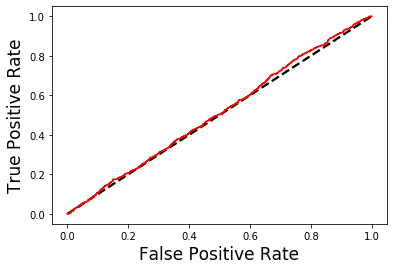

In [51]:
    lw = 2.3
    plt.plot([0, 1], [0, 1], 'k--', lw=lw)
    plt.plot(fpr,tpr, color = 'red', label = "AUC = {0:0.5f}".format(rocketPower)) #PC ROC curve (area = {0:0.5f})
    plt.xlabel("False Positive Rate", fontsize = 17)
    plt.ylabel("True Positive Rate", fontsize = 17)

In [52]:
rocketPower

0.5123953153350125

In [ ]:
all_probs=(model.fit(np.array(X_train).reshape(-1, 1), np.ravel(np.array(y_train).reshape(-1, 1))).predict(np.array(X_test).reshape(-1, 1)))